In [1]:
##Import LIbraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE

In [2]:
#Load Dataset
df = pd.read_csv('/content/creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nClass Counts:\n", df['Class'].value_counts())
print("\nClass Distribution (%):\n", df['Class'].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Class Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution (%):
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/tmp/ipykernel_2563/710622843.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


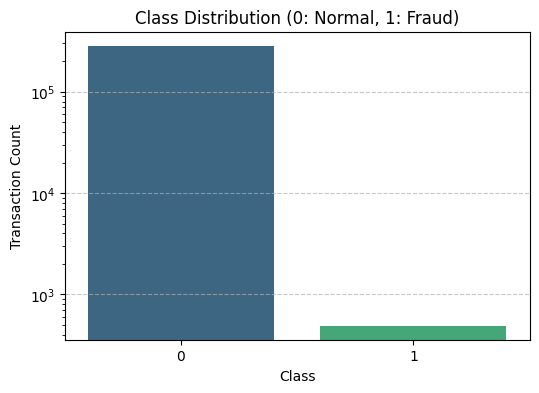

In [3]:
#Visualize the Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Transaction Count')
plt.yscale('log')  # Log scale highlights the rare fraud class clearly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
#Feature Scaling & Train-Test Split
# Scale the 'Amount' feature; V1-V28 are already PCA-transformed
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])

X = df.drop(columns=['Time', 'Amount', 'Class'])
y = df['Class']

# Stratified split ensures equal class proportion in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# Function to evaluate and print metrics cleanly
def evaluate_model(model, X_test_data, y_test_data, model_name="Model"):
    y_pred = model.predict(X_test_data)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_data, y_pred, average='binary')
    acc = model.score(X_test_data, y_test_data)

    print(f"=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    return {"Model": model_name, "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-Score": f1}

In [7]:
#Baseline Model (Unbalanced Data)
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

results = []
results.append(evaluate_model(baseline_model, X_test, y_test, "Baseline (Unbalanced)"))

=== Baseline (Unbalanced) ===
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1-Score : 0.7241



In [8]:
#Handling Imbalance Technique 1 - Class Weighting
weighted_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
weighted_model.fit(X_train, y_train)

results.append(evaluate_model(weighted_model, X_test, y_test, "Class Weighted (balanced)"))

=== Class Weighted (balanced) ===
Accuracy : 0.9746
Precision: 0.0588
Recall   : 0.9184
F1-Score : 0.1105



In [9]:
#Handling Imbalance Technique 2 - SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

results.append(evaluate_model(smote_model, X_test, y_test, "SMOTE Oversampled"))

=== SMOTE Oversampled ===
Accuracy : 0.9734
Precision: 0.0563
Recall   : 0.9184
F1-Score : 0.1061



In [10]:
#Comparison Table
results_df = pd.DataFrame(results)
print("=== Final Comparison Summary ===")
print(results_df.to_string(index=False))

=== Final Comparison Summary ===
                    Model  Accuracy  Precision   Recall  F1-Score
    Baseline (Unbalanced)  0.999157   0.828947 0.642857  0.724138
Class Weighted (balanced)  0.974562   0.058785 0.918367  0.110497
        SMOTE Oversampled  0.973368   0.056285 0.918367  0.106070


##**Why "Accuracy" is a Misleading Metric for Imbalanced Data**

In an imbalanced dataset like Credit Card Fraud Detection, Legitimate (Class 0) transactions represent 99.83% of the data, while Fraudulent (Class 1) transactions make up only 0.17%.The Majority Class Trap: A baseline classifier that blindly predicts every single transaction is legitimate (Class 0) without performing any actual analysis will achieve an accuracy of 99.83%.Failure in Real-World Purpose: Despite a high accuracy score, that baseline model catches 0 fraudulent transactions ($0\%$ Recall). In a real financial system, letting $100\%$ of fraud slip through leads to severe financial loss.The Correct Metrics:Recall (Sensitivity): Measures what percentage of actual fraud cases were successfully flagged.Precision: Measures how many flagged transactions were actually fraudulent (minimizing false alarms).F1-Score: The harmonic mean of Precision and Recall, providing a single balanced evaluation metric when class distribution is highly uneven.